# 00. Color Event 데이터 인벤토리와 ROI 가정

18번 실험은 신호등과 red line을 빠르게 구현하는 데 목적이 있었지만, 지금 단계에서는 값이 왜 선택됐는지 다시 납득할 수 있어야 한다.

이번 21번 폴더는 color event를 다시 정리한다.

- **traffic light**: 빨강/초록 신호등을 색 + contour로 탐지한다.
- **red line**: 하단 빨간 정지/도착선을 색 + contour로 탐지한다.
- **state machine**: 여기서는 아직 다루지 않는다. detector가 어떤 event 후보를 넘길지만 정한다.

이 00 노트북은 detector를 만들지 않는다. 먼저 데이터가 정상인지, 해상도와 파일명이 어떻게 되어 있는지, loose ROI를 어떤 가정으로 볼지 확인한다.

## 0. 왜 18번을 그대로 쓰지 않는가

18번의 결론을 완전히 버리는 것은 아니다. 다만 그대로 복사하지 않고 다음 순서로 다시 확인한다.

1. 데이터 인벤토리: 이미지 수, 해상도, class hint, 깨진 파일 여부
2. traffic detector: HSV/HLS 등 색 분리와 contour 후보를 다시 확인
3. redline detector: 하단 ROI와 수평 contour 후보를 다시 확인
4. event contract: detector 후보가 어느 순간 state machine에 event를 넘길지 정리

중요한 원칙은 다음과 같다.

- ROI는 처음부터 정답이 아니다. **초반에는 색과 형태가 분리되는지 보고**, 마지막에 event gate로 ROI를 좁힌다.
- traffic과 redline은 runtime에서 같은 OpenCV worker가 처리할 수 있지만, **실험 노트북에서는 분리해서 검증**한다.

In [1]:
from pathlib import Path
import json
import math
import random
import cv2
import numpy as np
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization")
DATA_ROOT = PROJECT_ROOT / "20_shared_assets" / "dataset"
TRAFFIC_ROOT = DATA_ROOT / "traffic"
REDLINE_ROOT = DATA_ROOT / "redline"

EXP_ROOT = PROJECT_ROOT / "10_experiments" / "21_color_event_contract"
OUT_ROOT = EXP_ROOT / "review_outputs" / "00_data_inventory_and_roi_assumptions"
TABLE_DIR = OUT_ROOT / "tables"
OVERLAY_DIR = OUT_ROOT / "overlays"
NOTE_DIR = OUT_ROOT / "notes"
for d in [TABLE_DIR, OVERLAY_DIR, NOTE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 0
SAMPLE_PER_GROUP = 16

print("traffic root:", TRAFFIC_ROOT)
print("redline root:", REDLINE_ROOT)
print("output root:", OUT_ROOT)

traffic root: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\traffic
redline root: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\redline
output root: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\21_color_event_contract\review_outputs\00_data_inventory_and_roi_assumptions


In [2]:
def imread_bgr(path):
    # Windows 한글 경로에서도 깨지지 않도록 np.fromfile + cv2.imdecode를 사용한다.
    path = Path(path)
    data = np.fromfile(str(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, cv2.IMREAD_COLOR)


def imwrite_bgr(path, bgr):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ext = path.suffix or ".jpg"
    ok, buf = cv2.imencode(ext, bgr)
    if not ok:
        raise RuntimeError(f"cv2.imencode failed: {path}")
    buf.tofile(str(path))


def infer_traffic_hint(path):
    name = Path(path).name.lower()
    parent = " ".join([p.lower() for p in Path(path).parts[-4:]])
    text = name + " " + parent
    if "green" in text or "go" in text:
        return "green"
    if "red" in text or "stop" in text:
        return "red"
    return "unknown"


def list_images(root, set_name):
    rows = []
    for path in sorted(Path(root).rglob("*.jpg")):
        if path.stat().st_size <= 0:
            rows.append({
                "set": set_name,
                "class_hint": "broken_zero_byte",
                "path": str(path),
                "filename": path.name,
                "size_bytes": path.stat().st_size,
                "width": None,
                "height": None,
                "read_ok": False,
            })
            continue
        bgr = imread_bgr(path)
        if bgr is None:
            h = w = None
            read_ok = False
        else:
            h, w = bgr.shape[:2]
            read_ok = True
        if set_name == "traffic":
            class_hint = infer_traffic_hint(path)
        else:
            class_hint = "redline"
        rows.append({
            "set": set_name,
            "class_hint": class_hint,
            "path": str(path),
            "filename": path.name,
            "size_bytes": path.stat().st_size,
            "width": w,
            "height": h,
            "read_ok": read_ok,
        })
    return rows

records = list_images(TRAFFIC_ROOT, "traffic") + list_images(REDLINE_ROOT, "redline")
df = pd.DataFrame(records)
df.to_csv(TABLE_DIR / "dataset_index.csv", index=False, encoding="utf-8-sig")

summary = (
    df.groupby(["set", "class_hint", "read_ok"], dropna=False)
      .size()
      .reset_index(name="count")
      .sort_values(["set", "class_hint", "read_ok"])
)
summary.to_csv(TABLE_DIR / "dataset_count_summary.csv", index=False, encoding="utf-8-sig")
display(summary)

size_summary = (
    df[df["read_ok"]]
    .groupby(["set", "class_hint", "width", "height"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values(["set", "class_hint", "count"], ascending=[True, True, False])
)
size_summary.to_csv(TABLE_DIR / "image_size_summary.csv", index=False, encoding="utf-8-sig")
display(size_summary.head(20))

,set,class_hint,read_ok,count
0,redline,redline,True,334
1,traffic,green,True,313
2,traffic,red,True,343


,set,class_hint,width,height,count
0,redline,redline,1296,972,334
1,traffic,green,1296,972,313
2,traffic,red,1296,972,343


## 1. 00 단계에서 보는 ROI는 최종값이 아니다

다음 ROI는 event 설계를 위한 **초기 가정**이다. detector의 성능 판단을 강하게 좌우하지 않도록 00에서는 sample overlay에만 표시한다.

- traffic light loose ROI: 이미지 오른쪽 절반
  - 표지판과 신호등은 주행 중 주로 오른쪽에 배치된다는 사전정보를 반영한다.
- redline loose ROI: 이미지 하단 40%
  - 최종 red line event는 차량 가까이에서만 의미가 있으므로 하단 영역을 본다.

다음 노트북에서 색/contour를 볼 때도, ROI는 처음부터 강하게 고정하지 않고 `no ROI → loose ROI → event ROI` 순서로 비교한다.

In [3]:
def draw_roi(bgr, roi, color=(0, 255, 255), thickness=3):
    h, w = bgr.shape[:2]
    x1 = int(round(roi["x_min"] * w))
    y1 = int(round(roi["y_min"] * h))
    x2 = int(round(roi["x_max"] * w))
    y2 = int(round(roi["y_max"] * h))
    out = bgr.copy()
    cv2.rectangle(out, (x1, y1), (x2, y2), color, thickness)
    return out

TRAFFIC_LOOSE_ROI = {"x_min": 0.50, "x_max": 1.00, "y_min": 0.00, "y_max": 1.00}
REDLINE_LOOSE_ROI = {"x_min": 0.00, "x_max": 1.00, "y_min": 0.60, "y_max": 1.00}

roi_assumptions = {
    "traffic_loose_roi": TRAFFIC_LOOSE_ROI,
    "redline_loose_roi": REDLINE_LOOSE_ROI,
    "note": "These are visualization assumptions for 00. Final ROI will be decided in later detector/event notebooks.",
}
with open(NOTE_DIR / "roi_assumptions_v0.json", "w", encoding="utf-8") as f:
    json.dump(roi_assumptions, f, ensure_ascii=False, indent=2)

roi_assumptions

{'traffic_loose_roi': {'x_min': 0.5, 'x_max': 1.0, 'y_min': 0.0, 'y_max': 1.0},
 'redline_loose_roi': {'x_min': 0.0, 'x_max': 1.0, 'y_min': 0.6, 'y_max': 1.0},
 'note': 'These are visualization assumptions for 00. Final ROI will be decided in later detector/event notebooks.'}

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\21_color_event_contract\review_outputs\00_data_inventory_and_roi_assumptions\overlays\sample_grid_traffic_green.jpg


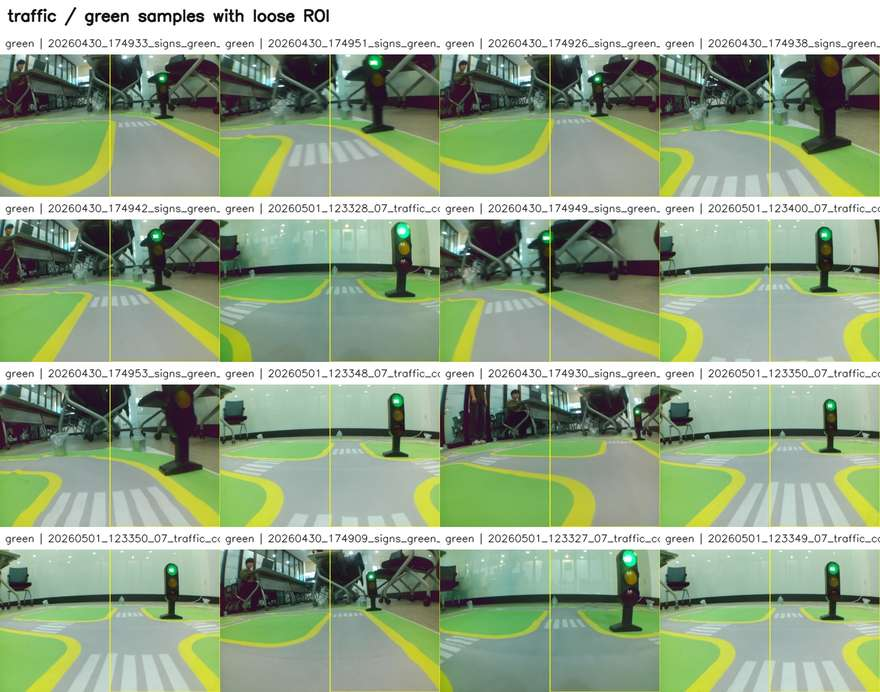

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\21_color_event_contract\review_outputs\00_data_inventory_and_roi_assumptions\overlays\sample_grid_traffic_red.jpg


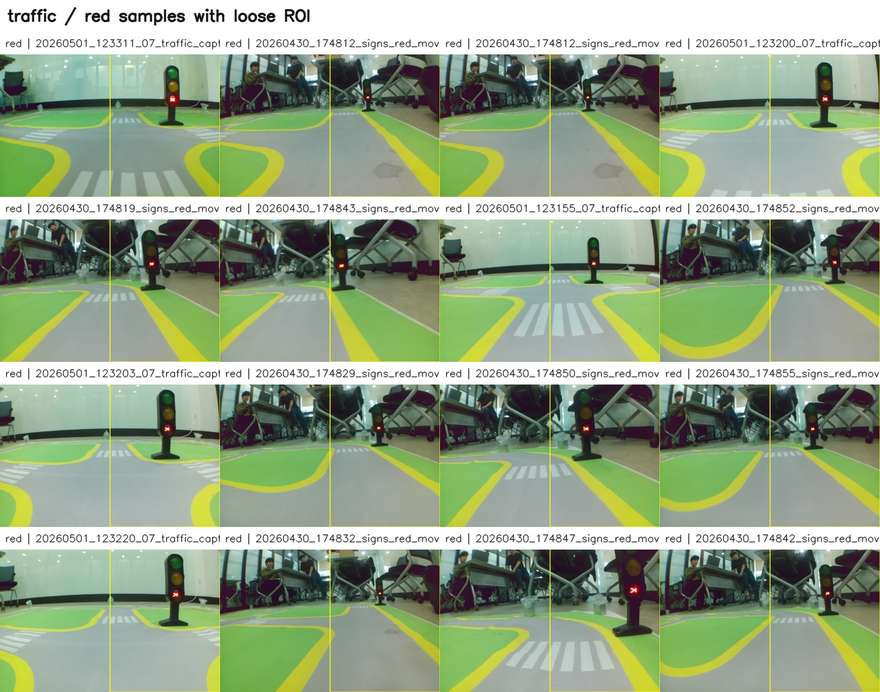

skip empty grid: traffic / unknown samples with loose ROI
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\21_color_event_contract\review_outputs\00_data_inventory_and_roi_assumptions\overlays\sample_grid_redline_redline.jpg


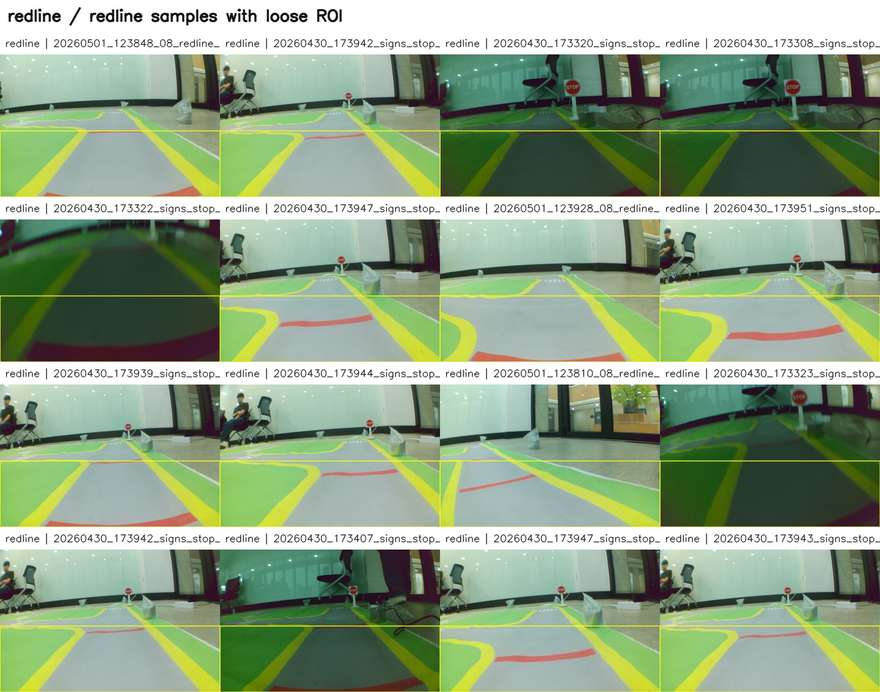

In [4]:
def resize_keep_aspect(bgr, target_w=360, target_h=270):
    h, w = bgr.shape[:2]
    scale = min(target_w / w, target_h / h)
    nw, nh = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(bgr, (nw, nh), interpolation=cv2.INTER_AREA)
    canvas = np.full((target_h, target_w, 3), 245, dtype=np.uint8)
    x0 = (target_w - nw) // 2
    y0 = (target_h - nh) // 2
    canvas[y0:y0+nh, x0:x0+nw] = resized
    return canvas


def put_label(bgr, text, y=24):
    out = bgr.copy()
    cv2.rectangle(out, (0, 0), (out.shape[1], 36), (255, 255, 255), -1)
    cv2.putText(out, text[:60], (8, y), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (30, 30, 30), 1, cv2.LINE_AA)
    return out


def make_sample_grid(rows, out_path, title, roi=None, max_items=16, cols=4):
    if len(rows) == 0:
        print("skip empty grid:", title)
        return None
    rows = list(rows)
    random.Random(RANDOM_SEED).shuffle(rows)
    rows = rows[:max_items]
    tiles = []
    for rec in rows:
        bgr = imread_bgr(rec["path"])
        if bgr is None:
            continue
        if roi is not None:
            bgr = draw_roi(bgr, roi)
        tile = resize_keep_aspect(bgr)
        label = f'{rec["class_hint"]} | {rec["filename"]}'
        tile = put_label(tile, label)
        tiles.append(tile)
    if not tiles:
        return None
    tile_h, tile_w = tiles[0].shape[:2]
    rows_n = int(math.ceil(len(tiles) / cols))
    grid = np.full((rows_n * tile_h + 52, cols * tile_w, 3), 255, dtype=np.uint8)
    cv2.putText(grid, title, (12, 34), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (20, 20, 20), 2, cv2.LINE_AA)
    for i, tile in enumerate(tiles):
        r, c = divmod(i, cols)
        y0 = 52 + r * tile_h
        x0 = c * tile_w
        grid[y0:y0+tile_h, x0:x0+tile_w] = tile
    imwrite_bgr(out_path, grid)
    return out_path

ok_df = df[df["read_ok"]].copy()
paths = []
for set_name, class_hint, roi in [
    ("traffic", "green", TRAFFIC_LOOSE_ROI),
    ("traffic", "red", TRAFFIC_LOOSE_ROI),
    ("traffic", "unknown", TRAFFIC_LOOSE_ROI),
    ("redline", "redline", REDLINE_LOOSE_ROI),
]:
    part = ok_df[(ok_df["set"] == set_name) & (ok_df["class_hint"] == class_hint)]
    out = OVERLAY_DIR / f"sample_grid_{set_name}_{class_hint}.jpg"
    path = make_sample_grid(part.to_dict("records"), out, f"{set_name} / {class_hint} samples with loose ROI", roi=roi)
    if path is not None:
        paths.append(path)
        print(path)
        display(Image(filename=str(path)))

In [5]:
def compute_basic_color_stats(row):
    bgr = imread_bgr(row["path"])
    if bgr is None:
        return None
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hls = cv2.cvtColor(bgr, cv2.COLOR_BGR2HLS)
    return {
        "set": row["set"],
        "class_hint": row["class_hint"],
        "filename": row["filename"],
        "b_mean": float(bgr[:, :, 0].mean()),
        "g_mean": float(bgr[:, :, 1].mean()),
        "r_mean": float(bgr[:, :, 2].mean()),
        "hsv_h_mean": float(hsv[:, :, 0].mean()),
        "hsv_s_mean": float(hsv[:, :, 1].mean()),
        "hsv_v_mean": float(hsv[:, :, 2].mean()),
        "hls_l_mean": float(hls[:, :, 1].mean()),
        "hls_s_mean": float(hls[:, :, 2].mean()),
    }

stat_rows = []
for row in ok_df.to_dict("records"):
    s = compute_basic_color_stats(row)
    if s is not None:
        stat_rows.append(s)
stat_df = pd.DataFrame(stat_rows)
stat_df.to_csv(TABLE_DIR / "basic_color_stats.csv", index=False, encoding="utf-8-sig")

display(
    stat_df.groupby(["set", "class_hint"])[["b_mean", "g_mean", "r_mean", "hsv_s_mean", "hsv_v_mean"]]
    .agg(["mean", "std", "min", "max"])
    .round(2)
)

b_mean                        g_mean                 \
                      mean    std    min     max    mean    std     min   
set     class_hint                                                        
redline redline     113.11  40.81  43.53  158.29  144.38  43.34   59.84   
traffic green       116.39  18.01  99.65  154.23  146.74  19.40  122.67   
        red         121.72  21.05  98.93  155.38  151.01  21.71  123.60   

                            r_mean                        hsv_s_mean         \
                       max    mean    std     min     max       mean    std   
set     class_hint                                                            
redline redline     188.37  118.01  46.28   49.73  164.15      83.86  30.31   
traffic green       187.12  124.28  16.29  105.75  161.34      68.58   7.81   
        red         185.74  130.44  18.76  108.82  161.66      64.58  10.16   

                                  hsv_v_mean                         
                      min     max       mean    std     min     max  
set     class_hint                                                   
redline redline     51.69  128.08     146.68  42.41   69.63  189.08  
traffic green       46.48   78.73     148.22  18.55  126.52  187.24  
        red         43.93   80.07     152.56  20.80  128.34  186.44

In [6]:
report = {
    "experiment": "21_color_event_contract",
    "notebook": "00_data_inventory_and_roi_assumptions",
    "traffic_images": int((df["set"] == "traffic").sum()),
    "redline_images": int((df["set"] == "redline").sum()),
    "read_failures": int((~df["read_ok"]).sum()),
    "traffic_class_counts": df[df["set"] == "traffic"]["class_hint"].value_counts(dropna=False).to_dict(),
    "redline_class_counts": df[df["set"] == "redline"]["class_hint"].value_counts(dropna=False).to_dict(),
    "roi_assumptions": roi_assumptions,
    "outputs": {
        "dataset_index": str(TABLE_DIR / "dataset_index.csv"),
        "dataset_count_summary": str(TABLE_DIR / "dataset_count_summary.csv"),
        "image_size_summary": str(TABLE_DIR / "image_size_summary.csv"),
        "basic_color_stats": str(TABLE_DIR / "basic_color_stats.csv"),
        "sample_grids": [str(p) for p in paths],
    },
    "next": [
        "01_traffic_detector_probe_v2: traffic red/green HSV + contour 재검토",
        "02_redline_detector_probe_v2: bottom redline HSV + horizontal contour 재검토",
        "03_color_event_state_contract_v1: event/state machine 연결 contract 작성",
    ],
}
with open(OUT_ROOT / "00_data_inventory_report_v1.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

notes_text = """# 00 Data Inventory Notes

- 00 노트북은 detector threshold를 확정하지 않는다.
- traffic과 redline 데이터 수, class hint, 해상도, 깨진 파일 여부를 확인한다.
- ROI는 sample overlay에만 표시한 loose assumption이다.
- 다음 단계에서 색 mask와 contour를 분리해서 다시 확인한다.
"""
with open(NOTE_DIR / "00_data_inventory_notes.md", "w", encoding="utf-8") as f:
    f.write(notes_text)

print(json.dumps(report, ensure_ascii=False, indent=2))

{
  "experiment": "21_color_event_contract",
  "notebook": "00_data_inventory_and_roi_assumptions",
  "traffic_images": 656,
  "redline_images": 334,
  "read_failures": 0,
  "traffic_class_counts": {
    "red": 343,
    "green": 313
  },
  "redline_class_counts": {
    "redline": 334
  },
  "roi_assumptions": {
    "traffic_loose_roi": {
      "x_min": 0.5,
      "x_max": 1.0,
      "y_min": 0.0,
      "y_max": 1.0
    },
    "redline_loose_roi": {
      "x_min": 0.0,
      "x_max": 1.0,
      "y_min": 0.6,
      "y_max": 1.0
    },
    "note": "These are visualization assumptions for 00. Final ROI will be decided in later detector/event notebooks."
  },
  "outputs": {
    "dataset_index": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_experiments\\21_color_event_contract\\review_outputs\\00_data_inventory_and_roi_assumptions\\tables\\dataset_index.csv",
    "dataset_count_summary": "~\\02_Projects\\University\\26-1_EmbeddedArtificialSystemOptimization\\10_e

## 2. 다음 작업

00에서 확인할 것은 단순하다.

- 이미지가 정상적으로 읽히는가?
- traffic green/red가 파일명 또는 폴더 구조에서 구분되는가?
- redline 이미지는 해상도와 시점이 일관적인가?
- loose ROI를 씌운 샘플을 봤을 때, event ROI를 나중에 좁힐 여지가 있는가?

이후 01에서는 traffic만 다룬다. 목표는 바로 contract를 확정하는 것이 아니라, 다음을 눈으로 확인하는 것이다.

1. HSV/HLS/YCrCb 중 어떤 색공간이 빨강/초록 신호등을 가장 잘 분리하는가
2. 색 mask에서 contour/blob 후보가 traffic light 형태로 잡히는가
3. ROI를 넣었을 때 false positive가 얼마나 줄고 true positive를 놓치지는 않는가